# Multivariate t (Student) Distribution

`MultivariateT(mean, cov, df)` generalizes Student's t-distribution to several dimensions -- the heavy-tailed counterpart of the `MultivariateNormal`. Each draw is a vector of correlated values; `cov` is the scale (shape) matrix and `df` sets the tail weight. As `df` grows it approaches a `MultivariateNormal(mean, cov)`.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [2]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).draw()

(0.4347251902462812, 0.4172712533636189)

## Simulate

Confirm the draws are 2-dimensional vectors.

In [3]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).sim(1000)

0,"(-0.30178944348373615, -0.9438203641101127)"
1,"(1.6487246425782323, 1.783635466904243)"
2,"(1.1737591185555059, -0.6188162899083092)"
3,"(-1.1472408709601272, -1.1414535197775537)"
4,"(-0.42493471810555083, -0.9338386449726672)"
5,"(-0.5500429069481978, 1.623753852788475)"
6,"(2.653710447652178, 0.49943902468136225)"
7,"(0.7547161888917125, -0.9081906877958648)"
8,"(2.11902157307271, 0.4093488779184273)"
...,...
999,"(0.6001718469458193, 1.3451195483772143)"


## Evaluate the pdf at a point

In [4]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).pdf([0, 0])

np.float64(0.15915494309189535)

## Relationship: each marginal is a Student's t

Each component of a multivariate t is a univariate Student's t with the same `df`, centered at that component's mean and scaled by the square root of its diagonal entry. Here the first component of `MultivariateT([3, 7], [[4, 0], [0, 9]], df=5)` is `3 + 2 * StudentT(5)` (location 3, scale sqrt(4) = 2).

Simulating... [██████████████████████████████] 10000/10000 (100%)


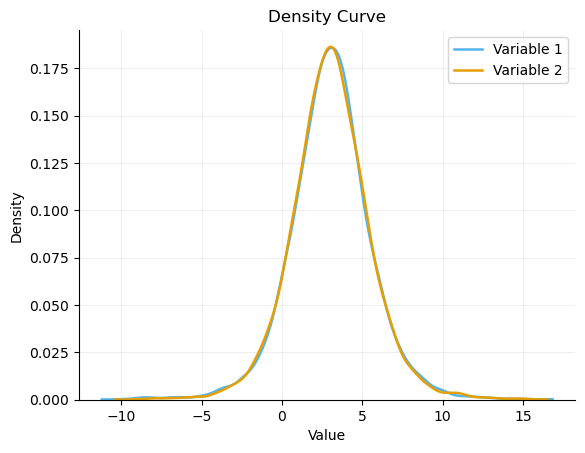

In [8]:
X, Y = RV(MultivariateT(mean=[3, 7], cov=[[4, 0], [0, 9]], df=5))
X.sim(10000).plot(type="density")
(3 + 2 * RV(StudentT(df=5))).sim(10000).plot(type="density")

## Relationship: large df approaches the multivariate normal

With `df = 1000` the marginal is indistinguishable from the corresponding normal.

Simulating... [██████████████████████████████] 10000/10000 (100%)


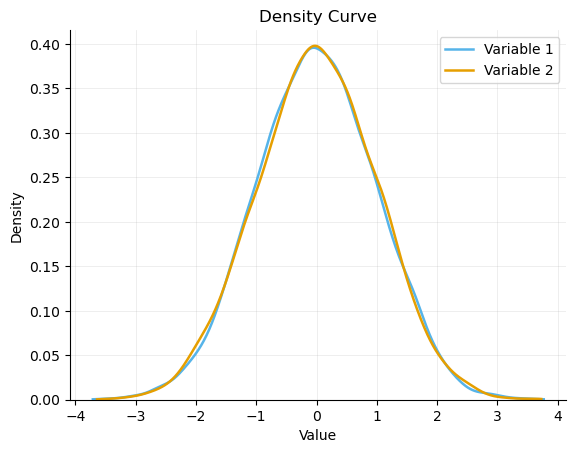

In [7]:
Xbig, _ = RV(MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=1000))
Xnorm, _ = RV(MultivariateNormal(mean=[0, 0], cov=[[1, 0], [0, 1]]))
Xbig.sim(10000).plot(type="density")
Xnorm.sim(10000).plot(type="density")